In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Sao chép file zip từ Drive về bộ nhớ tạm của Colab (chạy mất khoảng vài mươi giây)
!cp /content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/archive.zip /content/

# Giải nén file zip trực tiếp vào Colab
!unzip -o -q /content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/archive.zip -d /content/data/

Found 38301 images belonging to 3 classes.
Found 8212 images belonging to 3 classes.
Epoch 1/50
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4070 - loss: 1.4106
Epoch 1: val_accuracy improved from None to 0.48928, saving model to /content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/best_model.keras
599/599 ━━━━━━━━━━━━━━━━━━━━ 79s 97ms/step - accuracy: 0.4803 - loss: 1.2210 - val_accuracy: 0.4893 - val_loss: 1.3241 - learning_rate: 0.0010
Epoch 2/50
599/599 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6639 - loss: 0.8502
Epoch 2: val_accuracy improved from 0.48928 to 0.66013, saving model to /content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/best_model.keras
599/599 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - ac

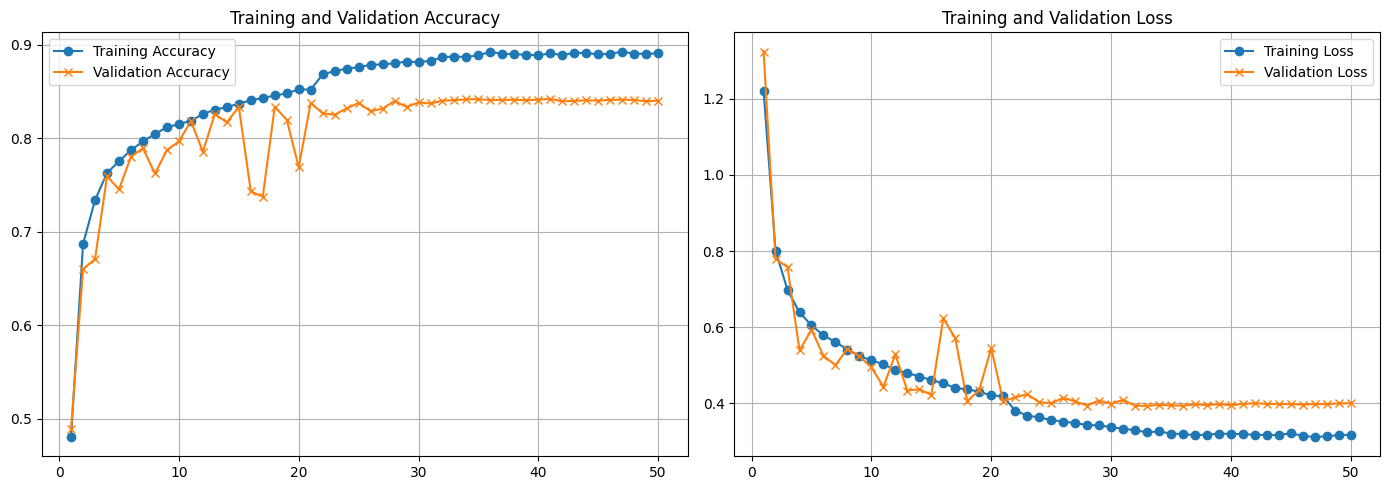

In [6]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Input, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# --- 1. Thiết lập dữ liệu nguồn ảnh (Data Augmentation đã được giảm nhẹ để dễ học) ---
train_data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,      # Giảm xoay để ổn định hơn
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
validation_data_gen = ImageDataGenerator(rescale=1./255)

# --- 2. Load dữ liệu ---
train_generator = train_data_gen.flow_from_directory(
    '/content/data/archive/train',
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_data_gen.flow_from_directory(
    '/content/data/archive/test',
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=False
)

# --- 3. Cấu trúc mô hình nâng cấp (Deep CNN) ---
emotion_model = Sequential([
    Input(shape=(48, 48, 1)),

    # Block 1
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Block 4
    Conv2D(512, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

# --- 4. Biên dịch và Callbacks (ĐÃ CẬP NHẬT MIN_LR) ---
emotion_model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001), # Tăng LR khởi đầu để học nhanh hơn
    metrics=['accuracy']
)

# Cấu hình ReduceLROnPlateau với min_lr=1e-5
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-5  # Đảm bảo tốc độ học không bị mất hoàn toàn
)

# Define the output directory in Google Drive
output_dir = '/content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/'
os.makedirs(output_dir, exist_ok=True)

# Lưu lại mô hình tốt nhất dựa trên val_accuracy
checkpoint_path = os.path.join(output_dir, 'best_model.keras')
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks_list = [lr_reducer, checkpoint]

# --- 5. Huấn luyện (ĐÃ CẬP NHẬT CLASS_WEIGHTS) ---
# Tăng nhẹ lớp Tiêu cực (1) để tránh bị lớp Trung tính (2) lấn át
class_weights = {0: 1.0, 1: 1.3, 2: 1.1}

emotion_model_info = emotion_model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=callbacks_list
)

# --- 6. Lưu trữ kết quả cuối cùng ---
# Lưu trọng số epoch cuối (song song với best_model đã lưu ở callback)
emotion_model.save_weights(os.path.join(output_dir, 'emotion_detection.weights.h5'))
with open(os.path.join(output_dir, 'emotion_detection.json'), "w") as json_file:
    json_file.write(emotion_model.to_json())

# Lưu lịch sử vào CSV
history_path = os.path.join(output_dir, 'training_history.csv')
history_df = pd.DataFrame(emotion_model_info.history)
history_df.to_csv(history_path, index=False)

print(f"✅ Đã lưu lịch sử huấn luyện vào: {history_path}")
print(f"✅ Đã lưu trọng số tốt nhất vào: {checkpoint_path}")

# --- 7. Vẽ biểu đồ ---
acc = emotion_model_info.history['accuracy']
val_acc = emotion_model_info.history['val_accuracy']
loss = emotion_model_info.history['loss']
val_loss = emotion_model_info.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Found 8212 images belonging to 3 classes.
Đang tính toán độ chính xác...
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.8421 - loss: 0.3979
Độ chính xác trên tập Test: 84.21%
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


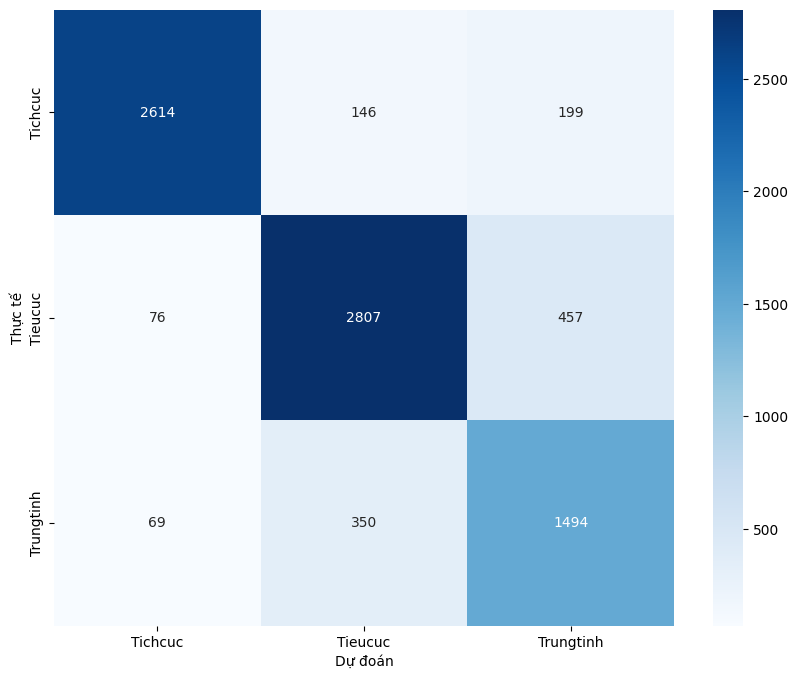

              precision    recall  f1-score   support

     Tichcuc       0.95      0.88      0.91      2959
     Tieucuc       0.85      0.84      0.85      3340
   Trungtinh       0.69      0.78      0.74      1913

    accuracy                           0.84      8212
   macro avg       0.83      0.83      0.83      8212
weighted avg       0.85      0.84      0.84      8212



In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load lại cấu trúc và trọng số (Giống Code 2)
json_file = open('/content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/emotion_detection.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
emotion_model = model_from_json(loaded_model_json)
emotion_model.load_weights('/content/drive/MyDrive/DATN_CHI_TRAM/model_emotiondetection/CNN_new/best_model.keras')

# 2. Load lại dữ liệu test để đánh giá
validation_data_gen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_data_gen.flow_from_directory(
    '/content/data/archive/test', # Corrected path based on typical unzip behavior
    target_size=(48, 48), # Đã sửa từ 48x48 -> 96x96
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical',
    shuffle=False
)

# 3. Đánh giá Accuracy tổng quát
print("Đang tính toán độ chính xác...")
# The .compile() method defines the loss function, optimizer, and metrics for training.
# It's usually called before training, but here it's called right before evaluation.
# Note: emotion_model.evaluate() does not return 'score' as the first element. It returns loss and metrics.
# The 'score' variable is not used after this line, so it doesn't affect the subsequent execution.
emotion_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
results = emotion_model.evaluate(validation_generator)
print(f"Độ chính xác trên tập Test: {results[1]*100:.2f}%")

# 4. Dự đoán và vẽ Ma trận nhầm lẫn
predictions = emotion_model.predict(validation_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# Vẽ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

# In báo cáo chi tiết
print(classification_report(y_true, y_pred, target_names=class_labels))